# T-Learner Uplift Modeling

This notebook implements the T-Learner meta-algorithm.

Two separate outcome models are trained:

- One on treated customers
- One on control customers

Uplift is estimated as the difference between predicted treated and control outcomes.

This directly approximates heterogeneous treatment effect.

## T-Learner Concept

The T-Learner fits two independent models:

1. Model trained on treated group
2. Model trained on control group

Uplift is computed as:

τ̂(x) = Ŷ_treated(x) − Ŷ_control(x)

This allows treatment effect to vary across individuals.

In [2]:
import sys, os
sys.path.append(os.path.abspath(".."))

import pandas as pd
from src.uplift_t_learner import TLearner

df = pd.read_csv("../data/simulated_campaign_data.csv")

X = df[["age","income","tenure","usage"]]
treatment = df["treatment"]
y = df["outcome"]

tlearner = TLearner()
tlearner.fit(X, treatment, y)

df["uplift_score"] = tlearner.predict_uplift(X)

df.head()

,age,income,tenure,usage,treatment,outcome,uplift_score
0,45.960570,49822.579043,0.171827,22.585829,1,0,-0.270
1,38.340828,55417.508054,12.756704,71.510244,1,1,0.390
2,47.772262,51039.284084,4.828591,47.126945,1,0,-0.325
3,58.276358,61656.270704,6.093305,48.104323,1,0,-0.645
4,37.190160,77957.677972,3.555397,49.399838,1,0,-0.425


### Model Interpretation

Each sub-model estimates outcome probability within a treatment regime.

The difference between predictions approximates individual treatment effect.

If uplift > 0:
Treatment increases probability of conversion.

If uplift < 0:
Treatment decreases probability of conversion.

In [6]:
df["uplift_score"].describe()

count    10000.000000
mean        -0.321587
std          0.339185
min         -0.970000
25%         -0.580000
50%         -0.420000
75%         -0.035000
max          0.745000
Name: uplift_score, dtype: float64

## Distribution of Estimated Uplift

Uplift scores are not constrained to be positive.

The distribution reveals:

- Magnitude of estimated treatment effect
- Presence of negative responders
- Spread of heterogeneity

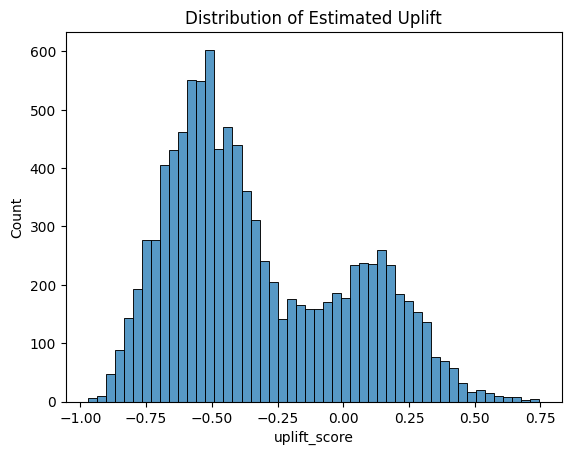

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["uplift_score"], bins=50)
plt.title("Distribution of Estimated Uplift")
plt.show()

## Uplift-Based Targeting Strategy

Customers are ranked by estimated uplift instead of predicted probability.

Targeting objective shifts from:

Maximize P(Y=1 | X)

to:

Maximize E[Y(1) − Y(0) | X]

Campaign economics remain unchanged.

In [8]:
COST = 10
MARGIN = 60
TARGET_RATIO = 0.3

df_uplift_sorted = df.sort_values("uplift_score", ascending=False)
top_k = int(len(df) * TARGET_RATIO)
targeted = df_uplift_sorted.head(top_k)

revenue = targeted["outcome"].sum() * MARGIN
cost = len(targeted) * COST
profit_uplift = revenue - cost

print("T-Learner Profit:", profit_uplift)

T-Learner Profit: 117780


### Profit Comparison

Compare:

- Random targeting
- Predictive probability targeting
- Uplift-based targeting

If uplift profit exceeds naive profit, causal modeling adds measurable economic value.

This demonstrates why outcome prediction alone is insufficient for optimal policy decisions.